# Maximum Likelihood Estimation (MLE)

This notebook **explains MLE** step by step 

MLE is like adjusting a dial to find the best-fit value that makes your observed data as likely as possible. We'll:
- Work through a coin flip example
- Visualize likelihood and log-likelihood curves
- Estimate parameters for normal data
- Add clear explanations

## Example: Estimating a Coin’s Bias
We flip a coin 20 times and get 14 heads. What’s the best estimate of the probability of heads? Let’s find out using MLE.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Data
n_trials = 20
n_heads = 14
theta_vals = np.linspace(0, 1, 200)
likelihoods = binom.pmf(n_heads, n_trials, theta_vals)

# Find MLE
mle_theta = theta_vals[np.argmax(likelihoods)]
print(f"MLE estimate of probability of heads: {mle_theta:.2f}")

MLE estimate of probability of heads: 0.70


## Likelihood Curve
We plot the likelihood of different θ values (probabilities of heads) and highlight the MLE.

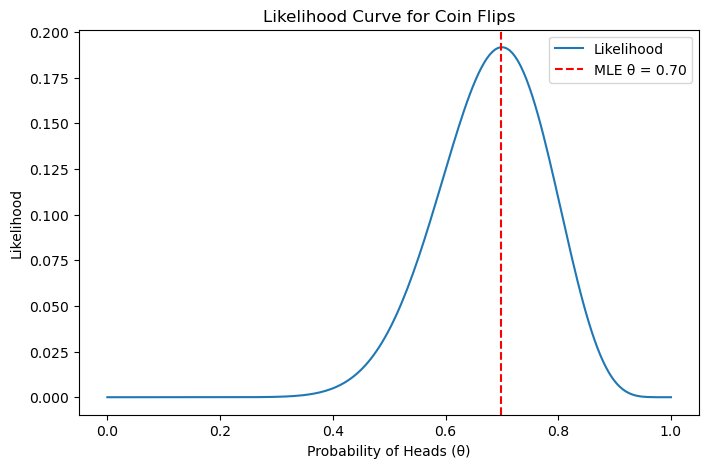

In [7]:
plt.figure(figsize=(8,5))
plt.plot(theta_vals, likelihoods, label='Likelihood')
plt.axvline(mle_theta, color='red', linestyle='--', label=f'MLE θ = {mle_theta:.2f}')
plt.title('Likelihood Curve for Coin Flips')
plt.xlabel('Probability of Heads (θ)')
plt.ylabel('Likelihood')
plt.legend()
plt.show()

## 🔍 Log-Likelihood Curve
We plot the **log-likelihood** to better see where the maximum happens.

/var/folders/qh/fmzc9db1783cz_z1bj3znn44y1tlxj/T/ipykernel_41734/1616151965.py:1: RuntimeWarning: divide by zero encountered in log
  log_likelihoods = np.log(likelihoods)


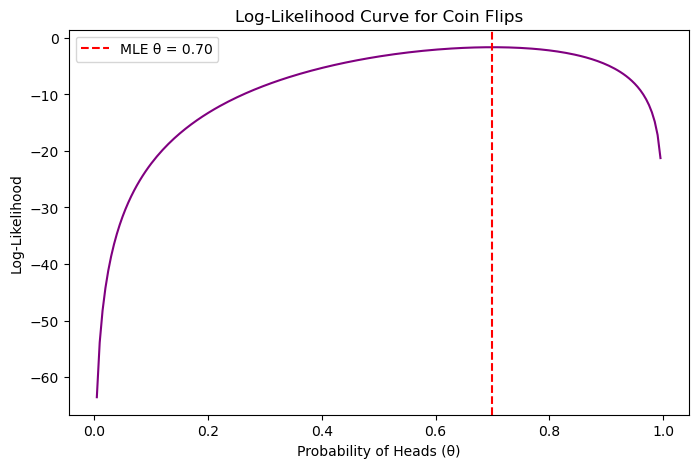

In [10]:
log_likelihoods = np.log(likelihoods)
plt.figure(figsize=(8,5))
plt.plot(theta_vals, log_likelihoods, color='purple')
plt.axvline(mle_theta, color='red', linestyle='--', label=f'MLE θ = {mle_theta:.2f}')
plt.title('Log-Likelihood Curve for Coin Flips')
plt.xlabel('Probability of Heads (θ)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.show()

## Example: Estimating the Mean of a Normal Distribution
We generate 100 data points from a normal distribution (mean = 50) and estimate the mean using MLE.

In [13]:
np.random.seed(42)
data = np.random.normal(50, 10, size=100)
mean_vals = np.linspace(45, 55, 200)
likelihoods_normal = [np.sum(-0.5 * ((data - mu)/10)**2) for mu in mean_vals]
mle_mean = mean_vals[np.argmax(likelihoods_normal)]
print(f"MLE estimate of the mean: {mle_mean:.2f}")

MLE estimate of the mean: 48.97


## Visualizing the Log-Likelihood for Mean
We plot the log-likelihood curve and highlight the MLE.

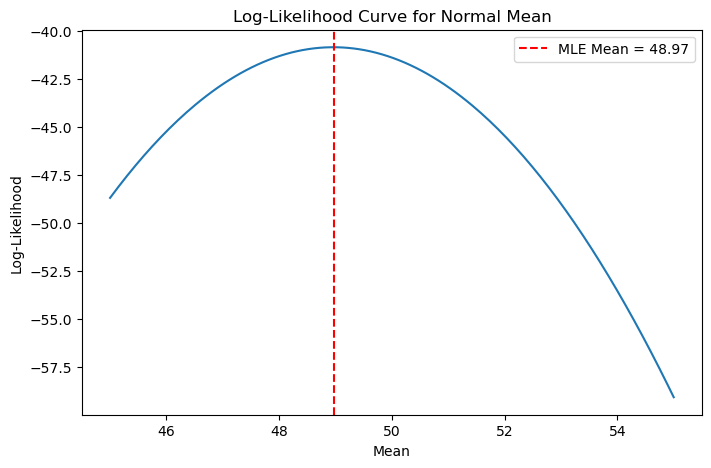

In [16]:
plt.figure(figsize=(8,5))
plt.plot(mean_vals, likelihoods_normal)
plt.axvline(mle_mean, color='red', linestyle='--', label=f'MLE Mean = {mle_mean:.2f}')
plt.title('Log-Likelihood Curve for Normal Mean')
plt.xlabel('Mean')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.show()

## Reflection
MLE is like finding the **sweet spot**, the parameter value that makes the data you saw the most 'believable.' Whether it’s a coin or a normal distribution, the process is the same: we test different guesses and keep the best one.